In [1]:
import xarray as xr
import numpy as np
from numpy import sqrt
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import wofz
import pandas as pd

### Define line profile, simple polynomial, BIC function, and composite fit builder function ###

In [2]:
def voigt_absorption(x, amp, center, sigma, gamma, offset):
    z = ((x - center) + 1j * gamma) / (sigma * np.sqrt(2))
    voigt_prof = np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi))
    if np.max(np.abs(voigt_prof)) == 0 or np.isnan(np.max(voigt_prof)):
        voigt_norm = np.zeros_like(voigt_prof)
    else:
        voigt_norm = voigt_prof / np.max(voigt_prof)
    return offset - amp * voigt_norm

def polynomial_degree_n(x, n, *coefficients):
    return sum(coefficients[i] * x**i for i in range(n + 1))

def calculate_bic(ssr, N, k):
    if N == 0:
        return np.inf
    return N * np.log(ssr / N) + k * np.log(N)
def build_composite_function(n):
    def composite_function(x, amp, center, sigma, gamma, offset, *coeffs):
        continuum = sum(c * x**i for i, c in enumerate(coeffs))
        return voigt_absorption(x, amp, center, sigma, gamma, offset) + continuum
    return composite_function

### Fitting Routine ###

In [ ]:
def fit_joint_model_with_bic(wavelength, flux, flux_error, lambda_0, w1, w2, max_order=3, min_bic_improvement=10, line_name=None, plot=False):
    mask = (wavelength > w1) & (wavelength < w2)
    x = wavelength[mask]
    y = flux[mask]
    yerr = flux_error[mask] if flux_error is not None else np.ones_like(y)

    best_bic = np.inf
    best_result = None
    no_improve_count = 0

    for n in range(max_order + 1):
        model = build_composite_function(n)

        #Guesses based on previous voigt fits
        offset_region = ((x > w1) & (x < (w1 + 15))) | ((x > (w2 - 15)) & (x < w2))
        #Estimate median from edge regions, but don't clip to 2.0
        offset_guess = np.median(y[offset_region])
        amp_guess = np.clip(offset_guess - np.min(y), 0.1, 10.0)
        center_guess = np.clip(x[np.argmin(y)], w1, w2)
        sigma_guess = 20.0
        gamma_guess = 35.0

        #Bounds based on previous fitting experiance
        lower_bounds = [1e-4, center_guess - 3.0, 0.0, 5.0, offset_guess - 10] + [-np.inf] * (n + 1)
        upper_bounds = [5.0, center_guess + 3.0, 60.0, 60.0, offset_guess + 10] + [np.inf] * (n + 1)

        voigt_guess = [amp_guess, center_guess, sigma_guess, gamma_guess, offset_guess]
        poly_guess = [0.0] * (n + 1)
        poly_guess[0] = offset_guess  #match continuum level

        p0 = voigt_guess + poly_guess

        for i, (val, low, high) in enumerate(zip(p0, lower_bounds, upper_bounds)):
            if not (low <= val <= high):
                print(f"Guess p0[{i}] = {val:.4f} out of bounds ({low:.4f}, {high:.4f})")

        try:
            popt, pcov = curve_fit(
                model, x, y, sigma=yerr,
                p0=p0, bounds=(lower_bounds, upper_bounds),
                maxfev=50000, absolute_sigma=True
            )
            #Print parameter breakdown
            amp, center, sigma, gamma, offset = popt[:5]
            print(f"[Order {n}] Voigt params:")
            print(f"  Amp = {amp:.3f}, Center = {center:.3f}, Sigma = {sigma:.3f}, Gamma = {gamma:.3f}, Offset = {offset:.3f}")

        except RuntimeError as e:
            print(f"Order {n} fit failed: {e}")
            no_improve_count += 1
            if no_improve_count >= 2:
                print("Early stopping due to consecutive failures.")
                break
            continue

        residuals = y - model(x, *popt)
        ssr = np.sum((residuals / yerr) ** 2)
        N = len(y)
        k = len(popt)
        bic = N * np.log(ssr / N) + k * np.log(N)

        print(f"Order {n}: BIC = {bic:.2f}")

        if bic < best_bic - min_bic_improvement:
            best_bic = bic
            best_result = (popt, pcov, n)
            no_improve_count = 0
        else:
            no_improve_count += 1
            if no_improve_count >= 2:
                print(f"Stopping early at order {n} due to no BIC improvement.")
                break

    if best_result is None:
        print("All fits failed.")
        return np.nan, np.nan, np.nan, np.nan

    popt, pcov, best_order = best_result
    amp, center, sigma, gamma, offset = popt[:5]
    center_err = np.sqrt(np.diag(pcov))[1]

    c_kms = 299792.458
    velocity = c_kms * (center - lambda_0) / lambda_0
    velocity_err = c_kms * center_err / lambda_0

    print(f"Order {n}: BIC = {bic:.2f}, SSR = {ssr:.2f}, k = {k}")

    if plot:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(7, 4))
        plt.errorbar(x, y, yerr=yerr, fmt='.', label='Data')
        plt.plot(x, build_composite_function(best_order)(x, *popt), label=f'Fit (order {best_order})')
        plt.xlabel("Wavelength")
        plt.ylabel("Flux")
        plt.title(f"{line_name or 'Line'} fit")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return center, center_err, velocity, velocity_err


### Load data and run it through the fitting routine ###

[Order 0] Voigt params:
  Amp = 0.278, Center = 6566.814, Sigma = 0.002, Gamma = 49.606, Offset = 0.724
Order 0: BIC = 367.39
[Order 1] Voigt params:
  Amp = 0.261, Center = 6566.468, Sigma = 0.000, Gamma = 39.495, Offset = 0.725
Order 1: BIC = 120.34
[Order 2] Voigt params:
  Amp = 0.215, Center = 6566.704, Sigma = 0.000, Gamma = 23.706, Offset = 0.724
Order 2: BIC = 65.77
[Order 3] Voigt params:
  Amp = 0.209, Center = 6566.128, Sigma = 0.000, Gamma = 21.505, Offset = 0.741
Order 3: BIC = 63.54
[Order 4] Voigt params:
  Amp = 0.306, Center = 6564.793, Sigma = 26.661, Gamma = 45.411, Offset = 0.753
Order 4: BIC = 249.97
[Order 5] Voigt params:
  Amp = 1.108, Center = 6563.813, Sigma = 29.230, Gamma = 21.152, Offset = 1.253
Order 5: BIC = 1823.70
Stopping early at order 5 due to no BIC improvement.
Order 5: BIC = 1823.70, SSR = 51531.27, k = 11


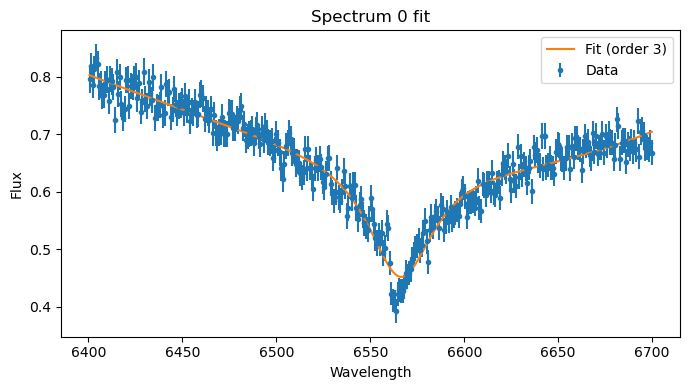

[Order 0] Voigt params:
  Amp = 0.282, Center = 6566.814, Sigma = 0.000, Gamma = 47.419, Offset = 0.724
Order 0: BIC = 744.67
[Order 1] Voigt params:
  Amp = 0.265, Center = 6566.814, Sigma = 0.000, Gamma = 37.612, Offset = 0.724
Order 1: BIC = 381.70
[Order 2] Voigt params:
  Amp = 0.222, Center = 6566.814, Sigma = 0.000, Gamma = 23.356, Offset = 0.995
Order 2: BIC = 307.67
[Order 3] Voigt params:
  Amp = 0.212, Center = 6566.814, Sigma = 0.103, Gamma = 21.329, Offset = 0.723
Order 3: BIC = 296.24
[Order 4] Voigt params:
  Amp = 0.183, Center = 6564.260, Sigma = 20.054, Gamma = 35.360, Offset = 0.736
Order 4: BIC = 818.61
[Order 5] Voigt params:
  Amp = 0.360, Center = 6563.815, Sigma = 26.015, Gamma = 41.468, Offset = 1.047
Order 5: BIC = 787.05
Stopping early at order 5 due to no BIC improvement.
Order 5: BIC = 787.05, SSR = 2733.31, k = 11
[Order 0] Voigt params:
  Amp = 0.274, Center = 6567.665, Sigma = 0.010, Gamma = 48.079, Offset = 0.724
Order 0: BIC = 384.84
[Order 1] Voigt pa

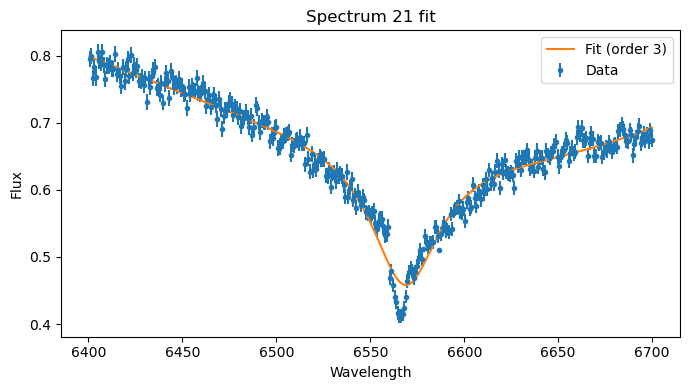

<xarray.Dataset> Size: 880B
Dimensions:                (time: 22)
Coordinates:
  * time                   (time) datetime64[ns] 176B 2025-02-27T14:20:46 ......
Data variables:
    radial_velocity        (time) float64 176B 152.5 183.8 222.7 ... 264.6 263.6
    radial_velocity_error  (time) float64 176B 8.17e-05 4.223e-05 ... 1.999e-05
    center                 (time) float64 176B 6.566e+03 6.567e+03 ... 6.569e+03
    center_error           (time) float64 176B 1.788e-06 9.244e-07 ... 4.375e-07


In [ ]:
ds = xr.open_dataset("SDSS1411/SDSS1411_spectra.nc")
wavelength = ds['wavelength'].values
flux_array = ds['flux_calibrated'].values
flux_error_array = ds['flux_calibrated_error'].values

wavelength_shifted = wavelength

num_spectra = flux_array.shape[0]

centers = []
center_errs = []
velocities = []
velocity_errs = []

for i in range(num_spectra):
    flux = flux_array[i, :]
    flux_err = flux_error_array[i, :]
    scale = np.nanmedian(np.abs(flux))
    if not np.isfinite(scale) or scale == 0:
        scale = 1.0

    flux = flux / scale
    flux_err = flux_err / scale
    
    center, center_err, velocity, velocity_err = fit_joint_model_with_bic(
        wavelength_shifted,
        flux,
        flux_error=flux_err,
        lambda_0=6562.79,  #this is H-alpha but edit for whichever line you're fitting
        w1=6400,
        w2=6700,
        line_name=f"Spectrum {i}",
        max_order=5,
        min_bic_improvement=0,
        plot=(i % 1 == 0)  #plot every nth (adjust as needed) spectrum for diagnostics
    )

    centers.append(center)
    center_errs.append(center_err)
    velocities.append(velocity)
    velocity_errs.append(velocity_err)

#Convert to xarrays
vel_da = xr.DataArray(
    data=velocities,
    coords={"time": ds.time},
    dims=["time"],
    name="radial_velocity",
    attrs={"units": "km/s", "description": "Radial velocity from centroid"}
)

center_da = xr.DataArray(
    data=centers,
    coords={"time": ds.time},
    dims=["time"],
    name="center",
    attrs={"units": "Angstrom", "description": "Fitted centroid of absorption"}
)

centroid_err_da = xr.DataArray(
    data=center_errs,
    coords={"time": ds.time},
    dims=["time"],
    name="center_error",
    attrs={"units": "Angstrom", "description": "Uncertainty in fitted centroid"}
)

vel_err_da = xr.DataArray(
    data=velocity_errs,
    coords={"time": ds.time},
    dims=["time"],
    name="radial_velocity_error",
    attrs={"units": "km/s", "description": "Uncertainty in radial velocity from centroid"}
)

fit_results_ds = xr.Dataset({
    "radial_velocity": vel_da,
    "radial_velocity_error": vel_err_da,
    "center": center_da,
    "center_error": centroid_err_da
})
print(fit_results_ds)
fit_results_ds.to_netcdf('SDSS1411_Ha_.nc')


### Fit sinusoid with uncertainty band ###

In [ ]:
#extract data
v = fit_results_ds['radial_velocity'].values
v_err = fit_results_ds['radial_velocity_error'].values
time = fit_results_ds['time'].values

#Remove NaNs
mask = ~np.isnan(v) & ~np.isnan(v_err) & ~np.isnan(time)
time = time[mask]
v = v[mask]
v_err = v_err[mask]

#Convert time to minutes since first observation
time0 = time[0]
time = (time - time0) / np.timedelta64(1, 'm')

#Define sinusoid model: v(t) = A * sin(2π f t + phi) + C
def sinusoid(t, A, f, phi, C):
    return A * np.sin(2 * np.pi * f * t + phi) + C

#Initial guess
A_guess = (np.nanmax(v) - np.nanmin(v)) / 2
f_guess = 1 / (time.max() - time.min())  #one full cycle
phi_guess = 0
C_guess = np.mean(v)

p0 = [A_guess, f_guess, phi_guess, C_guess]

#Fit to raw velocities
popt, pcov = curve_fit(sinusoid, time, v, sigma=v_err, absolute_sigma=True, p0=p0, maxfev=10000)
A_fit, f_fit, phi_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))
A_err, f_err, phi_err, C_err = perr

#Compute best-fit curve
time_fit = np.linspace(time.min(), time.max(), 1000)
v_fit = sinusoid(time_fit, *popt)

#Monte Carlo uncertainty band
n_samples = 1000
samples = np.random.multivariate_normal(popt, pcov, size=n_samples)
v_samples = np.array([sinusoid(time_fit, *s) for s in samples])
v_lower = np.percentile(v_samples, 16, axis=0)
v_upper = np.percentile(v_samples, 84, axis=0)

#Plot
plt.figure(figsize=(10, 5))
plt.errorbar(time, v, yerr=v_err, fmt='o', color='black', ecolor='gray', capsize=3, label='Data')
plt.plot(time_fit, v_fit, color='blue', label='Sinusoidal Fit')
plt.fill_between(time_fit, v_lower, v_upper, color='blue', alpha=0.2, label='1σ Confidence Band')
plt.title("Radial Velocity Fit")
plt.xlabel("Time [min]")
plt.ylabel("Radial Velocity [km/s]")
plt.axhline(C_fit, color='red', linestyle='--', linewidth=0.8, label=f'Fit Offset = {C_fit:.2f} km/s')
plt.legend()
plt.grid(True)

#Add fit parameters to plot
fit_label = (
    f"Amplitude = {A_fit:.2f} ± {A_err:.2f} km/s\n"
    f"Period = {1/f_fit:.2f} ± {(f_err / f_fit**2):.2f} min\n"
    f"Phase = {phi_fit:.2f} ± {phi_err:.2f} rad\n"
    f"Offset = {C_fit:.2f} ± {C_err:.2f} km/s"
)
plt.text(0.02, 0.98, fit_label, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', color='blue',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

plt.tight_layout()
plt.show()

#Print fitted parameters
print(f"Amplitude = {A_fit:.2f} ± {A_err:.2f} km/s")
print(f"Frequency = {f_fit:.5f} ± {f_err:.5f} cycles/min")
print(f"Period = {1/f_fit:.2f} ± {(f_err / f_fit**2):.2f} min")
print(f"Phase = {phi_fit:.2f} ± {phi_err:.2f} rad")
print(f"Offset = {C_fit:.2f} ± {C_err:.2f} km/s")

### Fit each spectrograph's results individually ###

Given the known differences between the left and right spectrograph's measurements, we can fit only odd/even indices to independently analyze the results for each spectrograph.

In [ ]:
###FIT EVENS###

#data extraction
v = fit_results_ds['radial_velocity'].values
v_err = fit_results_ds['radial_velocity_error'].values
time = fit_results_ds['time'].values


#Remove NaNs
mask = ~np.isnan(v) & ~np.isnan(v_err) & ~np.isnan(time)
time = time[mask]
v = v[mask]
v_err = v_err[mask]

#Keep only even indices
time = time[::2]
v = v[::2]
v_err = v_err[::2]


#Convert time to minutes since first observation
time0 = time[0]
time = (time - time0) / np.timedelta64(1, 'm') 

#Define sinusoid model: v(t) = A * sin(2π f t + phi) + C
def sinusoid(t, A, f, phi, C):
    return A * np.sin(2 * np.pi * f * t + phi) + C

#Initial guess
A_guess = (np.nanmax(v) - np.nanmin(v)) / 2
f_guess = 1 / (time.max() - time.min())  #one full cycle
phi_guess = 0
C_guess = np.mean(v)

p0 = [A_guess, f_guess, phi_guess, C_guess]

#Fit to raw velocities
popt, pcov = curve_fit(sinusoid, time, v, sigma=v_err, absolute_sigma=True, p0=p0)
A_fit, f_fit, phi_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))
A_err, f_err, phi_err, C_err = perr

#Compute best-fit curve
time_fit = np.linspace(time.min(), time.max(), 1000)
v_fit = sinusoid(time_fit, *popt)

#Monte Carlo uncertainty band
n_samples = 1000
samples = np.random.multivariate_normal(popt, pcov, size=n_samples)
v_samples = np.array([sinusoid(time_fit, *s) for s in samples])
v_lower = np.percentile(v_samples, 16, axis=0)
v_upper = np.percentile(v_samples, 84, axis=0)

#Plot
plt.figure(figsize=(10, 5))
plt.errorbar(time, v, yerr=v_err, fmt='o', color='black', ecolor='gray', capsize=3, label='Data')
plt.plot(time_fit, v_fit, color='blue', label='Sinusoidal Fit')
plt.fill_between(time_fit, v_lower, v_upper, color='blue', alpha=0.2, label='1σ Confidence Band')
plt.title("Radial Velocity Fit (evens)")
plt.xlabel("Time [min]")
plt.ylabel("Radial Velocity [km/s]")
plt.axhline(C_fit, color='red', linestyle='--', linewidth=0.8, label=f'Fit Offset = {C_fit:.2f} km/s')
plt.legend()
plt.grid(True)

#Add fit parameters to plot
fit_label = (
    f"Amplitude = {A_fit:.2f} ± {A_err:.2f} km/s\n"
    f"Period = {1/f_fit:.2f} ± {(f_err / f_fit**2):.2f} min\n"
    f"Phase = {phi_fit:.2f} ± {phi_err:.2f} rad\n"
    f"Offset = {C_fit:.2f} ± {C_err:.2f} km/s"
)
plt.text(0.02, 0.98, fit_label, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', color='blue',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

plt.tight_layout()
plt.show()

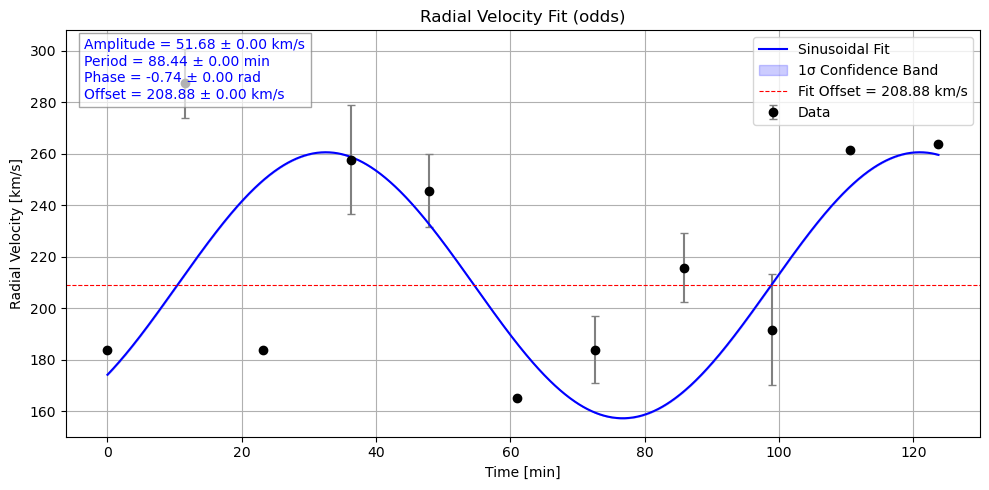

In [ ]:
###FIT ODDS###

#Data extraction
v = fit_results_ds['radial_velocity'].values
v_err = fit_results_ds['radial_velocity_error'].values
time = fit_results_ds['time'].values

#Remove NaNs
mask = ~np.isnan(v) & ~np.isnan(v_err) & ~np.isnan(time)
time = time[mask]
v = v[mask]
v_err = v_err[mask]

#Keep only even indices
time = time[1::2]
v = v[1::2]
v_err = v_err[1::2]


#Convert time to minutes since first observation
time0 = time[0]
time = (time - time0) / np.timedelta64(1, 'm') 

#Define sinusoid model: v(t) = A * sin(2π f t + phi) + C
def sinusoid(t, A, f, phi, C):
    return A * np.sin(2 * np.pi * f * t + phi) + C

#Initial guess
A_guess = (np.nanmax(v) - np.nanmin(v)) / 2
f_guess = 1 / (time.max() - time.min())  #one full cycle
phi_guess = 0
C_guess = np.mean(v)

p0 = [A_guess, f_guess, phi_guess, C_guess]

#Fit to raw velocities
popt, pcov = curve_fit(sinusoid, time, v, sigma=v_err, absolute_sigma=True, p0=p0)
A_fit, f_fit, phi_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))
A_err, f_err, phi_err, C_err = perr

#Compute best-fit curve
time_fit = np.linspace(time.min(), time.max(), 1000)
v_fit = sinusoid(time_fit, *popt)

#Monte Carlo uncertainty band
n_samples = 1000
samples = np.random.multivariate_normal(popt, pcov, size=n_samples)
v_samples = np.array([sinusoid(time_fit, *s) for s in samples])
v_lower = np.percentile(v_samples, 16, axis=0)
v_upper = np.percentile(v_samples, 84, axis=0)

#Plot
plt.figure(figsize=(10, 5))
plt.errorbar(time, v, yerr=v_err, fmt='o', color='black', ecolor='gray', capsize=3, label='Data')
plt.plot(time_fit, v_fit, color='blue', label='Sinusoidal Fit')
plt.fill_between(time_fit, v_lower, v_upper, color='blue', alpha=0.2, label='1σ Confidence Band')
plt.title("Radial Velocity Fit (odds)")
plt.xlabel("Time [min]")
plt.ylabel("Radial Velocity [km/s]")
plt.axhline(C_fit, color='red', linestyle='--', linewidth=0.8, label=f'Fit Offset = {C_fit:.2f} km/s')
plt.legend()
plt.grid(True)

#Add fit parameters to plot
fit_label = (
    f"Amplitude = {A_fit:.2f} ± {A_err:.2f} km/s\n"
    f"Period = {1/f_fit:.2f} ± {(f_err / f_fit**2):.2f} min\n"
    f"Phase = {phi_fit:.2f} ± {phi_err:.2f} rad\n"
    f"Offset = {C_fit:.2f} ± {C_err:.2f} km/s"
)
plt.text(0.02, 0.98, fit_label, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', color='blue',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

plt.tight_layout()
plt.show()

### We can also choose to fix the orbital period of the sinusoid to check our fit against the previous measurement ###

In [ ]:
#data extraction
v = fit_results_ds['radial_velocity'].values
v_err = fit_results_ds['radial_velocity_error'].values
time = fit_results_ds['time'].values

#Remove NaNs
mask = ~np.isnan(v) & ~np.isnan(v_err) & ~np.isnan(time)
v = v[mask]
v_err = v_err[mask]
time = time[mask]

#Convert time to minutes since first observation
time0 = time[0]
time = (time - time0) / np.timedelta64(1, 'm')

#Fixed period (known)
P_known = 71.2          #minutes
f_known = 1.0 / P_known  #cycles per minute

#Sinusoid with fixed frequency
def sinusoid_fixedP(t, A, phi, C):
    return A * np.sin(2 * np.pi * f_known * t + phi) + C

A_guess = 0.5 * (np.nanmax(v) - np.nanmin(v))
phi_guess = 0.0
C_guess = np.nanmean(v)
p0 = [A_guess, phi_guess, C_guess]

popt, pcov = curve_fit(
    sinusoid_fixedP,
    time,
    v,
    sigma=v_err,
    absolute_sigma=True,
    p0=p0,
)

A_fit, phi_fit, C_fit = popt
A_err, phi_err, C_err = np.sqrt(np.diag(pcov))

time_fit = np.linspace(time.min(), time.max(), 1000)
v_fit = sinusoid_fixedP(time_fit, *popt)

n_samples = 1000
samples = np.random.multivariate_normal(popt, pcov, size=n_samples)
v_samples = np.array([
    sinusoid_fixedP(time_fit, *s) for s in samples
])

v_lower = np.percentile(v_samples, 16, axis=0)
v_upper = np.percentile(v_samples, 84, axis=0)

plt.figure(figsize=(10, 5))
plt.errorbar(
    time, v, yerr=v_err,
    fmt='o', color='black', ecolor='gray',
    capsize=3, label='Data'
)
plt.plot(time_fit, v_fit, color='blue', label='Sinusoidal Fit (P = 71.2 min)')
plt.fill_between(
    time_fit, v_lower, v_upper,
    color='blue', alpha=0.2, label='1σ Confidence Band'
)
plt.axhline(
    C_fit, color='red', linestyle='--', linewidth=0.8,
    label=f'Fit Offset = {C_fit:.2f} km/s'
)

plt.title("Radial Velocity Fit (Fixed Period)")
plt.xlabel("Time [min]")
plt.ylabel("Radial Velocity [km/s]")
plt.legend()
plt.grid(True)

fit_label = (
    f"Amplitude = {A_fit:.2f} ± {A_err:.2f} km/s\n"
    f"Period = {P_known:.1f} min (fixed)\n"
    f"Phase = {phi_fit:.2f} ± {phi_err:.2f} rad\n"
    f"Offset = {C_fit:.2f} ± {C_err:.2f} km/s"
)

plt.text(
    0.02, 0.98, fit_label,
    transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.tight_layout()
plt.show()

print(f"Amplitude = {A_fit:.2f} ± {A_err:.2f} km/s")
print(f"Phase = {phi_fit:.3f} ± {phi_err:.3f} rad")
print(f"Offset = {C_fit:.2f} ± {C_err:.2f} km/s")
print(f"Period = {P_known:.1f} min (fixed)")


### Finally, save the results for each individual Balmer Line into one larger dataset ###

In [ ]:
# Define your input files
files = {
    'Halpha': 'rv_Halpha.nc',
    'Hbeta': 'rv_Hbeta.nc',
    'Hgamma': 'rv_Hgamma.nc',
    'Hdelta': 'rv_Hdelta.nc'
}

datasets = []

# Open the first file to use its 'time' as the master reference
ref_line, ref_file = next(iter(files.items()))
ref_ds = xr.open_dataset(ref_file)
time = ref_ds['time']
ref_ds = ref_ds.assign_coords(time=time)  # explicitly fix coordinate
ref_ds = ref_ds.expand_dims(line=[ref_line])
datasets.append(ref_ds)

# Now load the rest, reassigning 'time' from reference
for line, fname in list(files.items())[1:]:
    ds = xr.open_dataset(fname)
    ds = ds.assign_coords(time=time)  # force time alignment
    ds = ds.expand_dims(line=[line])
    datasets.append(ds)

# Combine along 'line' dimension
combined_ds = xr.concat(datasets, dim='line')

# Save to file
combined_ds.to_netcdf("combined_H_lines_rv.nc")



In [ ]:
print(combined_ds)